## Decision Tree Classifier Machine learning

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [51]:
df = pd.read_csv("car_evaluation.csv", header = None)

In [52]:
df.head()

,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


## Exploratory Data Analysis

In [53]:
df.shape

(1728, 7)

In [54]:
# Giving the column name
col_name = ['buying','maint','doors','person','lug_boot','safety','class']
df.columns = col_name
df.head()

,buying,maint,doors,person,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [55]:
df.tail()

,buying,maint,doors,person,lug_boot,safety,class
1723,low,low,5more,more,med,med,good
1724,low,low,5more,more,med,high,vgood
1725,low,low,5more,more,big,low,unacc
1726,low,low,5more,more,big,med,good
1727,low,low,5more,more,big,high,vgood


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   person    1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [57]:
for col in col_name:
    print(df[col].value_counts())

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
person
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [58]:
# Just trying more
for col in df.columns:
    print(df[col].value_counts())

buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64
person
2       576
4       576
more    576
Name: count, dtype: int64
lug_boot
small    576
med      576
big      576
Name: count, dtype: int64
safety
low     576
med     576
high    576
Name: count, dtype: int64
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [59]:
df['class'].value_counts()

class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64

## Missing Variables

In [60]:
df.isnull().sum()

buying      0
maint       0
doors       0
person      0
lug_boot    0
safety      0
class       0
dtype: int64

## Declare Feature vector and target variable

In [61]:
X = df.drop(['class'], axis =1)
y = df['class']

In [62]:
X

,buying,maint,doors,person,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med
...,...,...,...,...,...,...
1723,low,low,5more,more,med,med
1724,low,low,5more,more,med,high
1725,low,low,5more,more,big,low
1726,low,low,5more,more,big,med


In [63]:
y

0       unacc
1       unacc
2       unacc
3       unacc
4       unacc
        ...  
1723     good
1724    vgood
1725    unacc
1726     good
1727    vgood
Name: class, Length: 1728, dtype: object

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(X,y, test_size = 0.33, random_state = 42)

In [65]:
X_train.shape, y_train.shape

((1157, 6), (1157,))

In [66]:
X_train.head()

,buying,maint,doors,person,lug_boot,safety
48,vhigh,vhigh,3,more,med,low
468,high,vhigh,3,4,small,low
155,vhigh,high,3,more,small,high
1721,low,low,5more,more,small,high
1208,med,low,2,more,small,high


In [67]:
y_train.head()

48      unacc
468     unacc
155     unacc
1721     good
1208    unacc
Name: class, dtype: object

## Feature Engineering

In [68]:
X_train.dtypes

buying      object
maint       object
doors       object
person      object
lug_boot    object
safety      object
dtype: object

In [69]:
# Importing category encoders
import category_encoders as ce

In [70]:
# Encode variable with ordinal encodeing
encoder = ce.OrdinalEncoder(cols = ['buying','maint','doors','person','lug_boot','safety'])

In [71]:
X_train =encoder.fit_transform(X_train)

In [72]:
X_train

,buying,maint,doors,person,lug_boot,safety
48,1,1,1,1,1,1
468,2,1,1,2,2,1
155,1,2,1,1,2,2
1721,3,3,2,1,2,2
1208,4,3,3,1,2,2
...,...,...,...,...,...,...
1130,4,4,1,1,1,2
1294,4,3,2,1,3,3
860,2,3,2,1,1,2
1459,3,2,4,3,2,3


In [73]:
X_test = encoder.transform(X_test)

In [74]:
X_test

,buying,maint,doors,person,lug_boot,safety
599,2,2,4,3,1,2
1201,4,3,3,2,1,3
628,2,2,2,3,3,3
1498,3,2,2,2,1,3
1263,4,3,4,1,1,1
...,...,...,...,...,...,...
1034,4,2,4,3,3,2
341,1,3,3,2,3,2
147,1,2,1,2,1,1
360,1,3,1,2,2,1


In [75]:
X_train.dtypes

buying      int64
maint       int64
doors       int64
person      int64
lug_boot    int64
safety      int64
dtype: object

## Decision Tree Classifier with criterion gini index

In [76]:
# import DecisionTreeClassifier

from sklearn.tree import DecisionTreeClassifier

In [77]:
#insitiate the DecisionTreeClassifier model with criterion gini index

clf_gini = DecisionTreeClassifier(criterion = 'gini', max_depth = 3, random_state = 0)

In [78]:
#fit the model
clf_gini.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predict the Test set Result with criterion gini index

In [79]:
y_pred_gini = clf_gini.predict(X_test)

In [80]:
y_pred_gini

array(['unacc', 'acc', 'unacc', 'acc', 'unacc', 'acc', 'unacc', 'unacc',
       'acc', 'unacc', 'acc', 'acc', 'unacc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc',
       'unacc', 'unacc', 'unacc', 'acc', 'acc', 'acc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'acc', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'acc', 'unacc', 'unacc', 'unacc',
       'unacc', 'unacc', 'unacc', 'unacc', 'unacc', 'acc', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'acc', 'acc',
       'acc', 'unacc', 'unacc', 'acc', 'acc', 'unacc', 'acc', 'unacc',
       'unacc', 'unacc', 'acc', 'unacc', 'unacc', 'unacc', 'acc', 'unacc',
       'unacc', 'unacc', 'unacc', 'acc', 'acc', 'acc', 'unac

In [81]:
from sklearn.metrics import accuracy_score
print("Model accuracy with gini index: {0:0.4f}". format(accuracy_score(y_test,y_pred_gini)))

Model accuracy with gini index: 0.8021


In [82]:
## Compare the train-set and test-set accuracy

y_pred_train_gini = clf_gini.predict(X_train)
y_pred_train_gini

array(['unacc', 'unacc', 'unacc', ..., 'unacc', 'unacc', 'acc'],
      shape=(1157,), dtype=object)

In [83]:
print("Training-set accuracy score : {0:0.4f}". format(accuracy_score(y_train,y_pred_train_gini)))

Training-set accuracy score : 0.7865


# Visualize the Decision Tree

[Text(0.4, 0.875, 'x[5] <= 1.5\ngini = 0.455\nsamples = 1157\nvalue = [255, 49, 813, 40]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 386\nvalue = [0, 0, 386, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[3] <= 2.5\ngini = 0.577\nsamples = 771\nvalue = [255, 49, 427, 40]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[0] <= 2.5\ngini = 0.631\nsamples = 525\nvalue = [255.0, 49.0, 181.0, 40.0]'),
 Text(0.2, 0.125, 'gini = 0.496\nsamples = 271\nvalue = [124, 0, 147, 0]'),
 Text(0.6, 0.125, 'gini = 0.654\nsamples = 254\nvalue = [131, 49, 34, 40]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 246\nvalue = [0, 0, 246, 0]')]

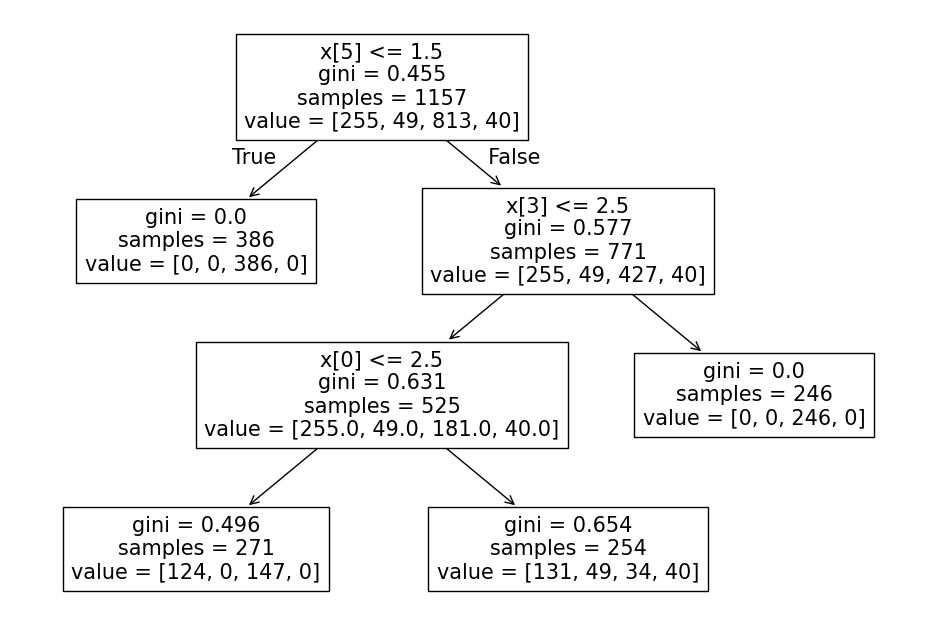

In [85]:
plt.figure(figsize = (12,8))
from sklearn import tree
tree.plot_tree(clf_gini.fit(X_train,y_train))

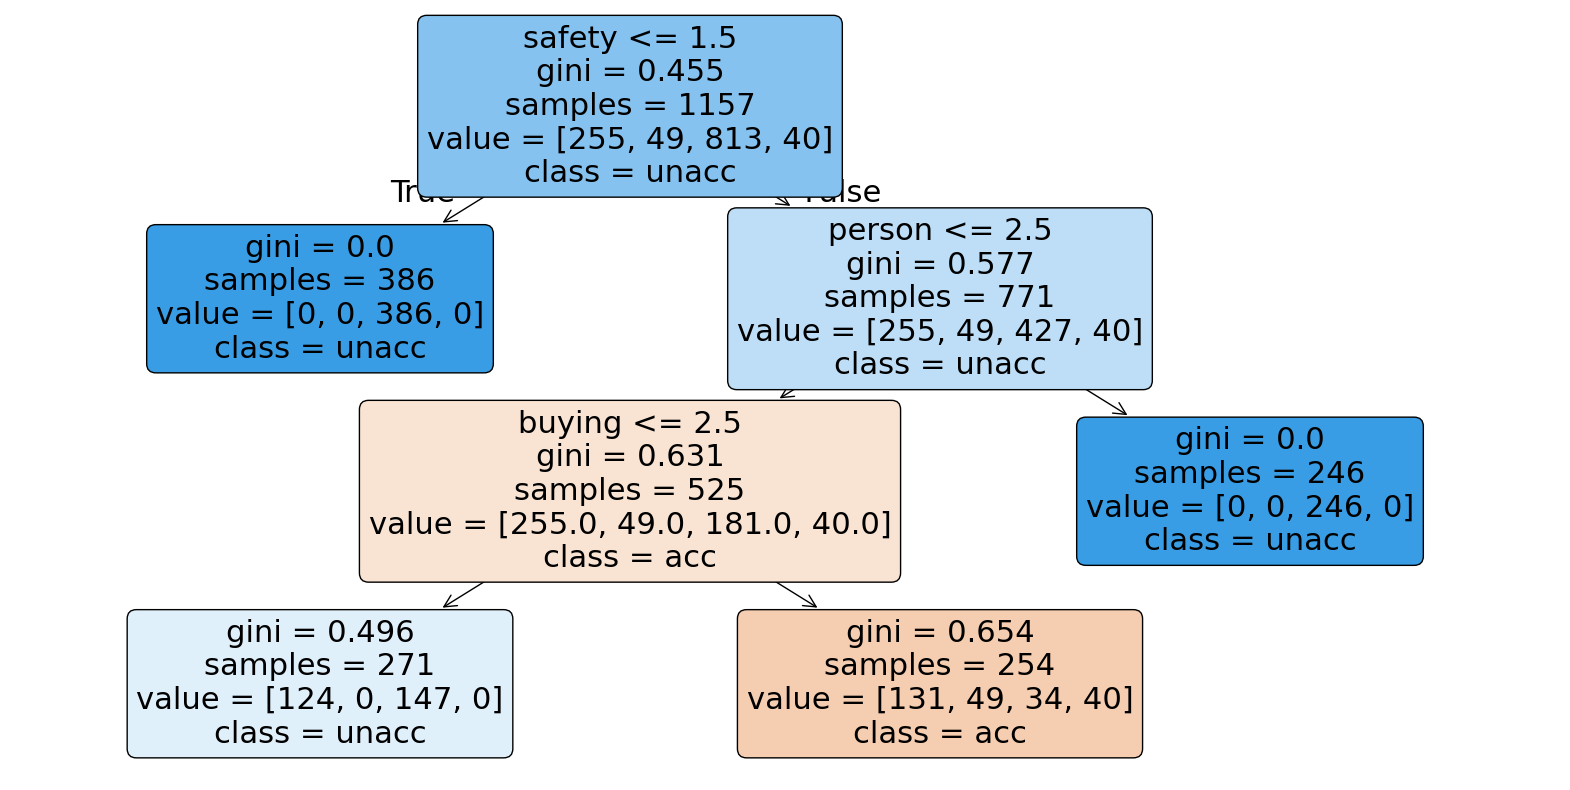

In [89]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.figure(figsize = (20,10))
plot_tree(clf_gini, feature_names = X.columns, class_names = clf_gini.classes_, filled = True, rounded = True)
plt.show()

## Decision Tree Classifier with citerion entropy

In [91]:
clf_en = DecisionTreeClassifier(criterion = 'entropy', max_depth=3 , random_state = 0)
clf_en.fit(X_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predict the test set result with Entropy

In [92]:
y_pred_en = clf_en.predict(X_test)

In [94]:
print("Model accuracy with entropy: {0:0.4f}". format(accuracy_score(y_test,y_pred_en)))

Model accuracy with entropy: 0.8021


In [95]:
## Compare the train-set and test-set accuracy

y_pred_train_en = clf_en.predict(X_train)
y_pred_train_en

array(['unacc', 'unacc', 'unacc', ..., 'unacc', 'unacc', 'acc'],
      shape=(1157,), dtype=object)

In [96]:
print("Training-set accuracy score on entropy: {0:0.4f}". format(accuracy_score(y_train,y_pred_train_en)))

Training-set accuracy score on entropy: 0.7865


[Text(0.4, 0.875, 'x[5] <= 1.5\nentropy = 1.2\nsamples = 1157\nvalue = [255, 49, 813, 40]'),
 Text(0.2, 0.625, 'entropy = 0.0\nsamples = 386\nvalue = [0, 0, 386, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[3] <= 2.5\nentropy = 1.474\nsamples = 771\nvalue = [255, 49, 427, 40]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[0] <= 2.5\nentropy = 1.638\nsamples = 525\nvalue = [255.0, 49.0, 181.0, 40.0]'),
 Text(0.2, 0.125, 'entropy = 0.995\nsamples = 271\nvalue = [124, 0, 147, 0]'),
 Text(0.6, 0.125, 'entropy = 1.759\nsamples = 254\nvalue = [131, 49, 34, 40]'),
 Text(0.8, 0.375, 'entropy = 0.0\nsamples = 246\nvalue = [0, 0, 246, 0]')]

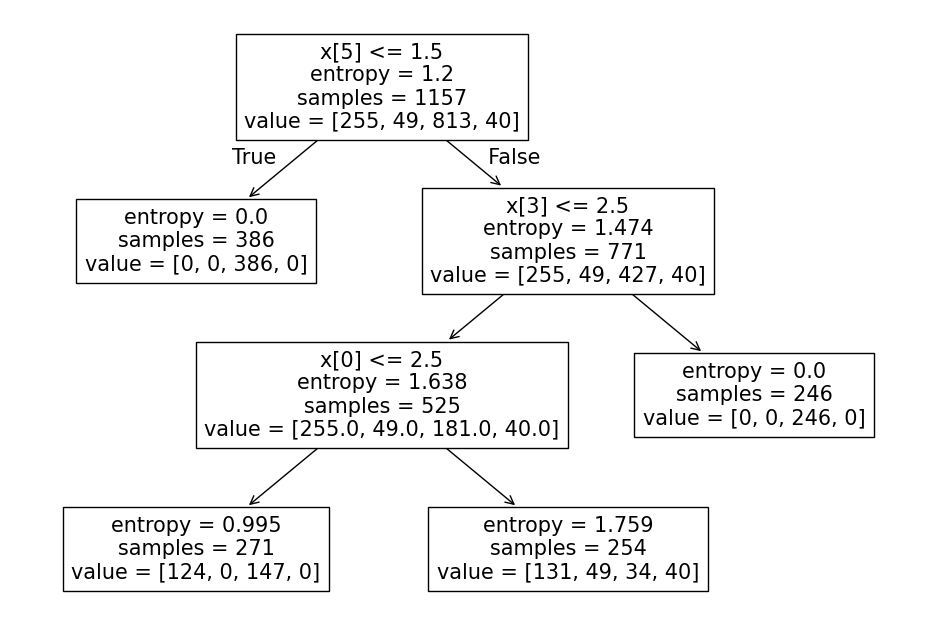

In [97]:
plt.figure(figsize = (12,8))
from sklearn import tree
tree.plot_tree(clf_en.fit(X_train,y_train))

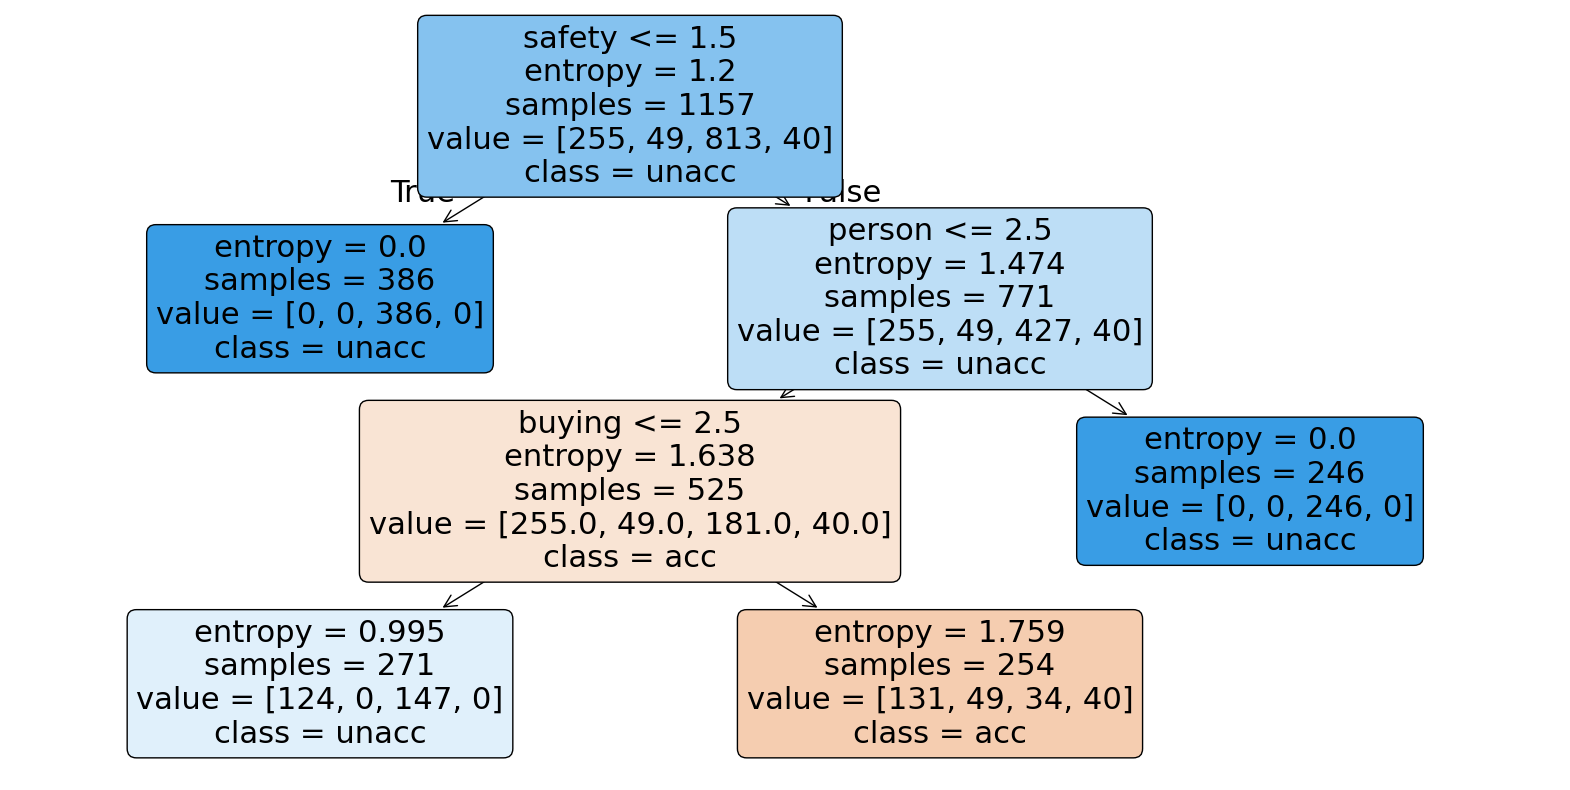

In [98]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.figure(figsize = (20,10))
plot_tree(clf_en, feature_names = X.columns, class_names = clf_en.classes_, filled = True, rounded = True)
plt.show()

## Confusion Matrix

In [99]:
#Print the confusion Matrix and slice it into four peace

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_en)
print("Confusion_Matrix:\n",cm)

Confusion_Matrix:
 [[ 73   0  56   0]
 [ 20   0   0   0]
 [ 12   0 385   0]
 [ 25   0   0   0]]


## Classification Report

In [100]:
from sklearn.metrics import classification_report
print("Classification_report:\n", classification_report(y_test, y_pred_en))

Classification_report:
               precision    recall  f1-score   support

         acc       0.56      0.57      0.56       129
        good       0.00      0.00      0.00        20
       unacc       0.87      0.97      0.92       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.80       571
   macro avg       0.36      0.38      0.37       571
weighted avg       0.73      0.80      0.77       571

